# Start-Page Classifier

Binary classification: **1 = start page ("yes")**, **0 = not start page**.

Five models:
1. **KNN + VGG16** – k-nearest neighbours on 4096-D VGG-16 features
2. **XGBoost + VGG16** – gradient boosting on VGG-16 features
3. **VGG16 (fine-tuned)** – end-to-end fine-tuning of VGG-16
4. **EfficientNet (fine-tuned)** – end-to-end fine-tuning of EfficientNet-B0
5. **LSTM + VGG16** – sequence model over per-page VGG-16 features within each dossier

**Data**:
- Images: `pdf_pages_png/<dossier>/<dossier>_page_XXXX.png`
- Labels: four annotators (`annotation 1–4.xlsx`)
  - 5 dossiers labelled by all 4 annotators → **majority vote** (≥ 2 of 4 say "yes" = 1)
  - 15 unique dossiers per annotator → single annotator label

## 1. Setup

In [1]:
import sys, os, warnings, pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
except ImportError:
    print('Installing xgboost …')
    os.system('pip install xgboost -q')
    from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

WORKSPACE = Path('')
PNG_ROOT   = WORKSPACE / 'pdf_pages_png'
CACHE_DIR  = WORKSPACE / 'feature_cache'
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

Device: cpu


## 2. Load annotations & build labels

In [2]:
def load_annotation(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df = df.dropna(subset=['image path']).copy()
    df['dossier'] = df['image path'].str.replace('.pdf', '', regex=False)
    df['page_num'] = pd.to_numeric(df['page number'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['page_num'])
    # normalise start-page label: 'yes' → 1, everything else → 0
    df['label'] = df['Start page'].astype(str).str.strip().str.lower().eq('yes').astype(int)
    return df[['dossier', 'page_num', 'label']]

ann = {i: load_annotation(WORKSPACE / f'annotation {i}.xlsx') for i in range(1, 5)}

# dossier sets
dossier_sets = {i: set(ann[i]['dossier'].unique()) for i in range(1, 5)}
common_dossiers = dossier_sets[1] & dossier_sets[2] & dossier_sets[3] & dossier_sets[4]
print(f'Common dossiers ({len(common_dossiers)}): {sorted(common_dossiers)}')

for i, s in dossier_sets.items():
    print(f'Annotation {i}: {len(s)} dossiers  |  unique: {len(s - common_dossiers)}')

Common dossiers (5): []Annotation 1: 20 dossiers  |  unique: 15
Annotation 2: 20 dossiers  |  unique: 15
Annotation 3: 20 dossiers  |  unique: 15
Annotation 4: 20 dossiers  |  unique: 15


In [3]:
# ── Majority-vote labels for the 5 shared dossiers ──────────────────────────
shared_frames = []
for i in range(1, 5):
    sub = ann[i][ann[i]['dossier'].isin(common_dossiers)].copy()
    sub = sub.rename(columns={'label': f'label_{i}'})
    shared_frames.append(sub.set_index(['dossier', 'page_num']))

shared = shared_frames[0].join(shared_frames[1], how='outer')\
                          .join(shared_frames[2], how='outer')\
                          .join(shared_frames[3], how='outer')
label_cols = [f'label_{i}' for i in range(1, 5)]
shared['votes'] = shared[label_cols].sum(axis=1)
# majority: >= 2 out of 4 annotators
shared['label'] = (shared['votes'] >= 2).astype(int)
shared = shared.reset_index()[['dossier', 'page_num', 'label']]
print(f'Shared dossiers pages: {len(shared)}  |  start-pages: {shared["label"].sum()}')

# ── Labels for the 15 unique dossiers per annotator ─────────────────────────
unique_frames = []
for i in range(1, 5):
    sub = ann[i][~ann[i]['dossier'].isin(common_dossiers)]
    unique_frames.append(sub[['dossier', 'page_num', 'label']])

unique_labels = pd.concat(unique_frames, ignore_index=True)
print(f'Unique dossiers pages: {len(unique_labels)}  |  start-pages: {unique_labels["label"].sum()}')

# ── Final label table ────────────────────────────────────────────────────────
all_labels = pd.concat([shared, unique_labels], ignore_index=True)
all_labels = all_labels.drop_duplicates(subset=['dossier', 'page_num'])
all_labels = all_labels.sort_values(['dossier', 'page_num']).reset_index(drop=True)
print(f'\nTotal pages: {len(all_labels)}  |  start-pages: {all_labels["label"].sum()}  '
      f'({all_labels["label"].mean()*100:.1f}%)')

all_labels.head(8)

Shared dossiers pages: 170  |  start-pages: 121
Unique dossiers pages: 2252  |  start-pages: 1581

Total pages: 2422  |  start-pages: 1702  (70.3%)


,dossier,page_num,label
0,a2478-ambachtsheer-p-1214053,1,1
1,a2478-ambachtsheer-p-1214053,2,1
2,a2478-ambachtsheer-p-1214053,3,0
3,a2478-ambachtsheer-p-1214053,4,1
4,a2478-ambachtsheer-p-1214053,5,0
5,a2478-ambachtsheer-p-1214053,6,1
6,a2478-ambachtsheer-p-1214053,7,1
7,a2478-ambachtsheer-p-1214053,8,0


## 3. Build image paths

In [4]:
def page_png_path(dossier: str, page_num: int) -> Path:
    return PNG_ROOT / dossier / f'{dossier}_page_{int(page_num):04d}.png'

all_labels['img_path'] = all_labels.apply(
    lambda r: page_png_path(r['dossier'], r['page_num']), axis=1
)

# keep only rows where the PNG actually exists
exists_mask = all_labels['img_path'].map(lambda p: p.exists())
missing = (~exists_mask).sum()
print(f'Missing PNGs: {missing} / {len(all_labels)}')
all_labels = all_labels[exists_mask].reset_index(drop=True)
print(f'Usable pages: {len(all_labels)}  |  start-pages: {all_labels["label"].sum()}')

all_labels.head(5)

Missing PNGs: 0 / 2422
Usable pages: 2422  |  start-pages: 1702


,dossier,page_num,label,img_path
0,a2478-ambachtsheer-p-1214053,1,1,/Users/yeqianli/Desktop/data segmentation/pdf_...
1,a2478-ambachtsheer-p-1214053,2,1,/Users/yeqianli/Desktop/data segmentation/pdf_...
2,a2478-ambachtsheer-p-1214053,3,0,/Users/yeqianli/Desktop/data segmentation/pdf_...
3,a2478-ambachtsheer-p-1214053,4,1,/Users/yeqianli/Desktop/data segmentation/pdf_...
4,a2478-ambachtsheer-p-1214053,5,0,/Users/yeqianli/Desktop/data segmentation/pdf_...


## 4. Train / Validation / Test split

Split is performed **at the dossier level** to avoid leakage (all pages of a dossier
stay in the same split).

In [5]:
dossiers_all = all_labels['dossier'].unique()

train_dos, tmp_dos = train_test_split(dossiers_all, test_size=0.30, random_state=RANDOM_SEED)
val_dos,   test_dos = train_test_split(tmp_dos,       test_size=0.50, random_state=RANDOM_SEED)

def split_label(d):
    if d in train_dos: return 'train'
    if d in val_dos:   return 'val'
    return 'test'

all_labels['split'] = all_labels['dossier'].map(split_label)

for s in ['train', 'val', 'test']:
    sub = all_labels[all_labels['split'] == s]
    print(f'{s:6s}: {len(sub):4d} pages  |  start-pages: {sub["label"].sum():3d} '
          f'({sub["label"].mean()*100:.1f}%)')

train : 1717 pages  |  start-pages: 1207 (70.3%)
val   :  367 pages  |  start-pages: 258 (70.3%)
test  :  338 pages  |  start-pages: 237 (70.1%)


## 5. Extract VGG-16 features (cached)

In [6]:
import sys
sys.path.insert(0, str(WORKSPACE))
from page_classifier_features import VGG16FeatureExtractor

FEAT_CACHE = CACHE_DIR / 'vgg16_features.npz'

if FEAT_CACHE.exists():
    print('Loading cached VGG-16 features …')
    cache = np.load(FEAT_CACHE, allow_pickle=True)
    X_all     = cache['X_all']
    y_all     = cache['y_all']
    path_strs = cache['path_strs']
    print(f'Loaded {X_all.shape}')
else:
    print('Extracting VGG-16 features (this may take a while) …')
    extractor = VGG16FeatureExtractor(device=DEVICE)
    paths = all_labels['img_path'].tolist()
    X_all = extractor.encode_paths(paths, batch_size=16)
    y_all = all_labels['label'].values.astype(np.int32)
    path_strs = np.array([str(p) for p in paths])
    np.savez(FEAT_CACHE, X_all=X_all, y_all=y_all, path_strs=path_strs)
    print(f'Extracted & cached: {X_all.shape}')

all_labels['feat_idx'] = np.arange(len(all_labels))

def get_split_features(split_name):
    idx = all_labels[all_labels['split'] == split_name].index
    return X_all[idx], y_all[idx]

X_tr, y_tr = get_split_features('train')
X_va, y_va = get_split_features('val')
X_te, y_te = get_split_features('test')
print(f'Train: {X_tr.shape}, Val: {X_va.shape}, Test: {X_te.shape}')

Extracting VGG-16 features (this may take a while) …
Extracted & cached: (2422, 4096)
Train: (1717, 4096), Val: (367, 4096), Test: (338, 4096)


## 6. Utility – evaluation helper

In [7]:
results_summary = {}

def evaluate_model(name, y_true, y_pred, y_prob=None):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None and len(np.unique(y_true)) > 1 else float('nan')
    results_summary[name] = {
        'accuracy':  report['accuracy'],
        'precision': report['1']['precision'],
        'recall':    report['1']['recall'],
        'f1':        report['1']['f1-score'],
        'roc_auc':   auc,
    }
    print(f'\n{'─'*60}')
    print(f'  {name}')
    print(f'{'─'*60}')
    print(classification_report(y_true, y_pred, target_names=['not-start (0)', 'start (1)'], zero_division=0))
    print(f'  ROC-AUC: {auc:.4f}')

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=['not-start', 'start']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

## 7. Model 1 – KNN + VGG-16

k= 3  val-F1=0.9441
k= 5  val-F1=0.9580
k= 7  val-F1=0.9562
k=11  val-F1=0.9600
k=15  val-F1=0.9421

Best k=11

────────────────────────────────────────────────────────────
  KNN + VGG-16
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.87      0.73      0.80       101
    start (1)       0.89      0.95      0.92       237

     accuracy                           0.89       338
    macro avg       0.88      0.84      0.86       338
 weighted avg       0.89      0.89      0.88       338

  ROC-AUC: 0.9409


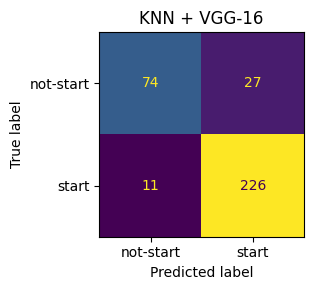

In [8]:
# L2-normalise features (good practice for cosine-like KNN)
from sklearn.preprocessing import normalize

X_tr_n = normalize(X_tr)
X_va_n = normalize(X_va)
X_te_n = normalize(X_te)

# tune k on validation set
best_k, best_f1 = 5, -1
for k in [3, 5, 7, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(X_tr_n, y_tr)
    preds = knn.predict(X_va_n)
    from sklearn.metrics import f1_score
    f1 = f1_score(y_va, preds, zero_division=0)
    print(f'k={k:2d}  val-F1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_k = f1, k

print(f'\nBest k={best_k}')
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_final.fit(np.vstack([X_tr_n, X_va_n]), np.concatenate([y_tr, y_va]))

knn_pred = knn_final.predict(X_te_n)
# KNN probability (k-NN does not give clean probabilities, use predict_proba anyway)
knn_prob = knn_final.predict_proba(X_te_n)[:, 1]

evaluate_model('KNN + VGG-16', y_te, knn_pred, knn_prob)

## 8. Model 2 – XGBoost + VGG-16

scale_pos_weight = 0.42

────────────────────────────────────────────────────────────
  XGBoost + VGG-16
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.88      0.92      0.90       101
    start (1)       0.97      0.95      0.96       237

     accuracy                           0.94       338
    macro avg       0.92      0.93      0.93       338
 weighted avg       0.94      0.94      0.94       338

  ROC-AUC: 0.9695


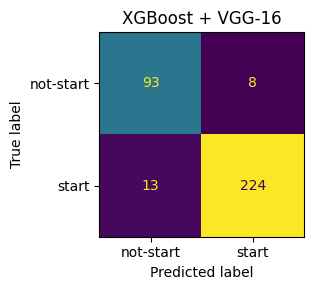

In [9]:
# class-weight balance
pos_weight = float((y_tr == 0).sum()) / max((y_tr == 1).sum(), 1)
print(f'scale_pos_weight = {pos_weight:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
    early_stopping_rounds=20,
    verbosity=0,
)
xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

xgb_pred = xgb.predict(X_te)
xgb_prob = xgb.predict_proba(X_te)[:, 1]

evaluate_model('XGBoost + VGG-16', y_te, xgb_pred, xgb_prob)

## 9. Model 3 – VGG-16 (fine-tuned end-to-end)

In [10]:
class PageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths  = df['img_path'].tolist()
        self.labels = df['label'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.long)


vgg_weights  = models.VGG16_Weights.IMAGENET1K_V1
train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
eval_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

tr_df = all_labels[all_labels['split'] == 'train']
va_df = all_labels[all_labels['split'] == 'val']
te_df = all_labels[all_labels['split'] == 'test']

tr_loader = DataLoader(PageDataset(tr_df, train_tfm), batch_size=16, shuffle=True,  num_workers=0)
va_loader = DataLoader(PageDataset(va_df, eval_tfm),  batch_size=32, shuffle=False, num_workers=0)
te_loader = DataLoader(PageDataset(te_df, eval_tfm),  batch_size=32, shuffle=False, num_workers=0)

print(f'Train batches: {len(tr_loader)}, Val batches: {len(va_loader)}, Test batches: {len(te_loader)}')

Train batches: 108, Val batches: 12, Test batches: 11


In [13]:
def build_vgg16_classifier():
    model = models.vgg16(weights=vgg_weights)
    # freeze feature layers, fine-tune classifier
    for p in model.features.parameters():
        p.requires_grad = False
    model.classifier[6] = nn.Linear(4096, 2)
    return model.to(DEVICE)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def train_model(model, tr_loader, va_loader, n_epochs=15, lr=1e-4, name='model'):
    pos_w = torch.tensor(
        [1.0, float((y_tr == 0).sum()) / max((y_tr == 1).sum(), 1)],
        dtype=torch.float32,
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=pos_w)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_f1, best_state = -1, None
    history = []
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, tr_loader, criterion, optimizer)
        va_loss, va_acc = eval_epoch(model, va_loader, criterion)
        _, va_pred, va_prob = predict_loader(model, va_loader)
        _, va_true, _    = predict_loader(model, va_loader)   # labels
        from sklearn.metrics import f1_score
        va_lbl = np.array(va_loader.dataset.labels)
        val_f1 = f1_score(va_lbl, va_pred, zero_division=0)
        scheduler.step()
        history.append((tr_loss, tr_acc, va_loss, va_acc, val_f1))
        print(f'Epoch {epoch:2d}  tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  '
              f'va_loss={va_loss:.4f}  va_acc={va_acc:.4f}  val_f1={val_f1:.4f}')
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return history


vgg16_model = build_vgg16_classifier()
print(f'Trainable params: {sum(p.numel() for p in vgg16_model.parameters() if p.requires_grad):,}')

Trainable params: 119,554,050


Epoch  1  tr_loss=0.4407  tr_acc=0.8043  va_loss=0.1977  va_acc=0.9264  val_f1=0.9461
Epoch  2  tr_loss=0.3106  tr_acc=0.8829  va_loss=0.1892  va_acc=0.9292  val_f1=0.9480
Epoch  3  tr_loss=0.2654  tr_acc=0.8992  va_loss=0.2022  va_acc=0.9319  val_f1=0.9518
Epoch  4  tr_loss=0.2223  tr_acc=0.9208  va_loss=0.2479  va_acc=0.8692  val_f1=0.8992
Epoch  5  tr_loss=0.1851  tr_acc=0.9342  va_loss=0.2003  va_acc=0.9428  val_f1=0.9594
Epoch  6  tr_loss=0.1224  tr_acc=0.9569  va_loss=0.2141  va_acc=0.9537  val_f1=0.9671
Epoch  7  tr_loss=0.1035  tr_acc=0.9668  va_loss=0.1978  va_acc=0.9401  val_f1=0.9565
Epoch  8  tr_loss=0.0981  tr_acc=0.9639  va_loss=0.2605  va_acc=0.9183  val_f1=0.9393
Epoch  9  tr_loss=0.0773  tr_acc=0.9703  va_loss=0.2245  va_acc=0.9373  val_f1=0.9553
Epoch 10  tr_loss=0.0834  tr_acc=0.9715  va_loss=0.2344  va_acc=0.9428  val_f1=0.9584
Epoch 11  tr_loss=0.0530  tr_acc=0.9819  va_loss=0.2495  va_acc=0.9482  val_f1=0.9634
Epoch 12  tr_loss=0.0432  tr_acc=0.9849  va_loss=0.281

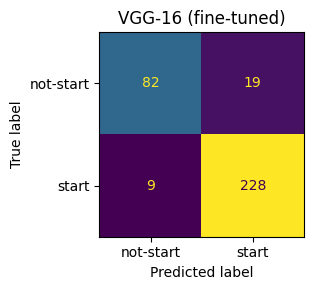

In [14]:
vgg16_history = train_model(vgg16_model, tr_loader, va_loader, n_epochs=15, lr=1e-4, name='VGG-16')

vgg16_te_lbl, vgg16_te_pred, vgg16_te_prob = predict_loader(vgg16_model, te_loader)
evaluate_model('VGG-16 (fine-tuned)', vgg16_te_lbl, vgg16_te_pred, vgg16_te_prob)

## 10. Model 4 – EfficientNet-B0 (fine-tuned)

Trainable params: 4,007,734
Epoch  1  tr_loss=0.6187  tr_acc=0.6610  va_loss=0.4495  va_acc=0.8202  val_f1=0.8608
Epoch  2  tr_loss=0.4339  tr_acc=0.8235  va_loss=0.2820  va_acc=0.9074  val_f1=0.9333
Epoch  3  tr_loss=0.3180  tr_acc=0.8806  va_loss=0.2332  va_acc=0.9183  val_f1=0.9412
Epoch  4  tr_loss=0.2638  tr_acc=0.8969  va_loss=0.2288  va_acc=0.9264  val_f1=0.9474
Epoch  5  tr_loss=0.2112  tr_acc=0.9196  va_loss=0.1931  va_acc=0.9373  val_f1=0.9552
Epoch  6  tr_loss=0.1626  tr_acc=0.9412  va_loss=0.1955  va_acc=0.9373  val_f1=0.9550
Epoch  7  tr_loss=0.1344  tr_acc=0.9546  va_loss=0.1807  va_acc=0.9319  val_f1=0.9505
Epoch  8  tr_loss=0.1329  tr_acc=0.9569  va_loss=0.1921  va_acc=0.9292  val_f1=0.9490
Epoch  9  tr_loss=0.1270  tr_acc=0.9546  va_loss=0.1835  va_acc=0.9292  val_f1=0.9480
Epoch 10  tr_loss=0.1072  tr_acc=0.9610  va_loss=0.1830  va_acc=0.9455  val_f1=0.9611
Epoch 11  tr_loss=0.0882  tr_acc=0.9680  va_loss=0.2009  va_acc=0.9401  val_f1=0.9574
Epoch 12  tr_loss=0.0834  

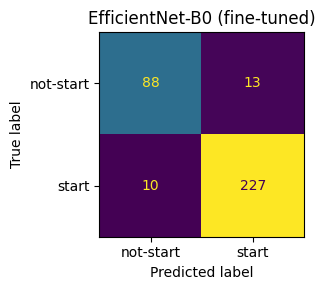

In [16]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_efficientnet():
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = efficientnet_b0(weights=weights)
    # freeze early layers
    for name, p in model.named_parameters():
        if 'features.0' in name or 'features.1' in name:
            p.requires_grad = False
    # replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 2)
    return model.to(DEVICE)


# EfficientNet uses 224×224 as well; reuse the same loaders
eff_model   = build_efficientnet()
print(f'Trainable params: {sum(p.numel() for p in eff_model.parameters() if p.requires_grad):,}')

eff_history = train_model(eff_model, tr_loader, va_loader, n_epochs=15, lr=5e-5, name='EfficientNet')

eff_te_lbl, eff_te_pred, eff_te_prob = predict_loader(eff_model, te_loader)
evaluate_model('EfficientNet-B0 (fine-tuned)', eff_te_lbl, eff_te_pred, eff_te_prob)

## 11. Model 5 – LSTM + VGG-16

Each dossier is treated as a sequence of pages. The VGG-16 features for each page are
fed into an LSTM; the LSTM's per-step hidden state is passed through a linear head to
predict whether that page is a start page.

In [17]:
class DossierSequenceDataset(Dataset):
    """
    Each item is one dossier: (features_seq, labels_seq) where
      features_seq : (T, 4096) float32
      labels_seq   : (T,)      int64
    """
    def __init__(self, df: pd.DataFrame, X_feat: np.ndarray):
        self.sequences = []
        for dossier, grp in df.groupby('dossier'):
            idx  = grp.index.tolist()
            feats = X_feat[idx]           # (T, 4096)
            lbls  = df.loc[idx, 'label'].values
            self.sequences.append(
                (torch.tensor(feats, dtype=torch.float32),
                 torch.tensor(lbls,  dtype=torch.long))
            )

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def pad_collate(batch):
    feats_list, lbls_list = zip(*batch)
    lengths = torch.tensor([f.size(0) for f in feats_list])
    feats_padded = nn.utils.rnn.pad_sequence(feats_list, batch_first=True)
    lbls_padded  = nn.utils.rnn.pad_sequence(lbls_list,  batch_first=True, padding_value=-1)
    return feats_padded, lbls_padded, lengths


lstm_tr_ds = DossierSequenceDataset(all_labels[all_labels['split'] == 'train'], X_all)
lstm_va_ds = DossierSequenceDataset(all_labels[all_labels['split'] == 'val'],   X_all)
lstm_te_ds = DossierSequenceDataset(all_labels[all_labels['split'] == 'test'],  X_all)

lstm_tr_loader = DataLoader(lstm_tr_ds, batch_size=4, shuffle=True,  collate_fn=pad_collate)
lstm_va_loader = DataLoader(lstm_va_ds, batch_size=4, shuffle=False, collate_fn=pad_collate)
lstm_te_loader = DataLoader(lstm_te_ds, batch_size=4, shuffle=False, collate_fn=pad_collate)

print(f'Train dossiers: {len(lstm_tr_ds)}, Val: {len(lstm_va_ds)}, Test: {len(lstm_te_ds)}')

Train dossiers: 45, Val: 10, Test: 10


In [18]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.head = nn.Linear(hidden_dim * 2, 2)   # bidirectional → ×2

    def forward(self, x, lengths=None):
        x = self.proj(x)                           # (B, T, 512)
        if lengths is not None:
            x = nn.utils.rnn.pack_padded_sequence(
                x, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
        out, _ = self.lstm(x)
        if lengths is not None:
            out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        logits = self.head(out)                    # (B, T, 2)
        return logits


def train_lstm(model, tr_loader, va_loader, n_epochs=20, lr=1e-3):
    pos_w = torch.tensor(
        [1.0, float((y_tr == 0).sum()) / max((y_tr == 1).sum(), 1)],
        dtype=torch.float32,
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=pos_w, ignore_index=-1)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    best_val_f1, best_state = -1, None
    from sklearn.metrics import f1_score

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss, n = 0, 0
        for feats, lbls, lengths in tr_loader:
            feats, lbls = feats.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            logits = model(feats, lengths)          # (B, T, 2)
            B, T, C = logits.shape
            loss = criterion(logits.view(B * T, C), lbls.view(B * T))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            mask = lbls.view(B * T) != -1
            total_loss += loss.item() * mask.sum().item()
            n          += mask.sum().item()
        scheduler.step()

        # validation F1
        model.eval()
        all_p, all_t = [], []
        with torch.no_grad():
            for feats, lbls, lengths in va_loader:
                feats = feats.to(DEVICE)
                logits = model(feats, lengths)
                B, T, C = logits.shape
                preds = logits.argmax(-1).cpu().numpy().ravel()
                truth = lbls.numpy().ravel()
                mask  = truth != -1
                all_p.extend(preds[mask])
                all_t.extend(truth[mask])
        val_f1 = f1_score(all_t, all_p, zero_division=0)
        print(f'Epoch {epoch:2d}  loss={total_loss/max(n,1):.4f}  val_f1={val_f1:.4f}')
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


lstm_model = LSTMClassifier(input_dim=4096, hidden_dim=256, num_layers=2, dropout=0.3).to(DEVICE)
print(f'LSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}')

lstm_model = train_lstm(lstm_model, lstm_tr_loader, lstm_va_loader, n_epochs=20, lr=1e-3)

LSTM params: 5,252,610
Epoch  1  loss=0.6623  val_f1=0.6580
Epoch  2  loss=0.4161  val_f1=0.9423
Epoch  3  loss=0.2830  val_f1=0.9643
Epoch  4  loss=0.2102  val_f1=0.9325
Epoch  5  loss=0.2033  val_f1=0.9581
Epoch  6  loss=0.1563  val_f1=0.9669
Epoch  7  loss=0.1400  val_f1=0.9562
Epoch  8  loss=0.1042  val_f1=0.9667
Epoch  9  loss=0.0911  val_f1=0.9667
Epoch 10  loss=0.0799  val_f1=0.9669
Epoch 11  loss=0.0656  val_f1=0.9480
Epoch 12  loss=0.0584  val_f1=0.9461
Epoch 13  loss=0.0587  val_f1=0.9648
Epoch 14  loss=0.0451  val_f1=0.9653
Epoch 15  loss=0.0418  val_f1=0.9546
Epoch 16  loss=0.0289  val_f1=0.9670
Epoch 17  loss=0.0217  val_f1=0.9526
Epoch 18  loss=0.0194  val_f1=0.9548
Epoch 19  loss=0.0180  val_f1=0.9689
Epoch 20  loss=0.0146  val_f1=0.9546



────────────────────────────────────────────────────────────
  LSTM + VGG-16
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.94      0.95      0.95       101
    start (1)       0.98      0.97      0.98       237

     accuracy                           0.97       338
    macro avg       0.96      0.96      0.96       338
 weighted avg       0.97      0.97      0.97       338

  ROC-AUC: 0.9831


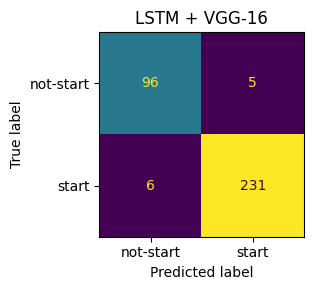

In [19]:
lstm_model.eval()
all_true_lstm, all_pred_lstm, all_prob_lstm = [], [], []
with torch.no_grad():
    for feats, lbls, lengths in lstm_te_loader:
        feats = feats.to(DEVICE)
        logits = lstm_model(feats, lengths)        # (B, T, 2)
        probs  = torch.softmax(logits, dim=-1)[..., 1]   # (B, T)
        preds  = logits.argmax(-1)                        # (B, T)
        truth  = lbls.numpy()
        mask   = truth != -1
        all_true_lstm.extend(truth[mask].tolist())
        all_pred_lstm.extend(preds.cpu().numpy()[mask].tolist())
        all_prob_lstm.extend(probs.cpu().numpy()[mask].tolist())

evaluate_model('LSTM + VGG-16', np.array(all_true_lstm),
               np.array(all_pred_lstm), np.array(all_prob_lstm))

## 12. Summary

In [20]:
summary_df = pd.DataFrame(results_summary).T
summary_df = summary_df.round(4)
summary_df.index.name = 'Model'
print(summary_df.to_string())
summary_df

                              accuracy  precision  recall      f1  roc_auc
Model                                                                     
KNN + VGG-16                    0.8876     0.8933  0.9536  0.9224   0.9409
XGBoost + VGG-16                0.9379     0.9655  0.9451  0.9552   0.9695
VGG-16 (fine-tuned)             0.9172     0.9231  0.9620  0.9421   0.9505
EfficientNet-B0 (fine-tuned)    0.9320     0.9458  0.9578  0.9518   0.9777
LSTM + VGG-16                   0.9675     0.9788  0.9747  0.9767   0.9831


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
KNN + VGG-16,0.8876,0.8933,0.9536,0.9224,0.9409
XGBoost + VGG-16,0.9379,0.9655,0.9451,0.9552,0.9695
VGG-16 (fine-tuned),0.9172,0.9231,0.9620,0.9421,0.9505
EfficientNet-B0 (fine-tuned),0.9320,0.9458,0.9578,0.9518,0.9777
LSTM + VGG-16,0.9675,0.9788,0.9747,0.9767,0.9831


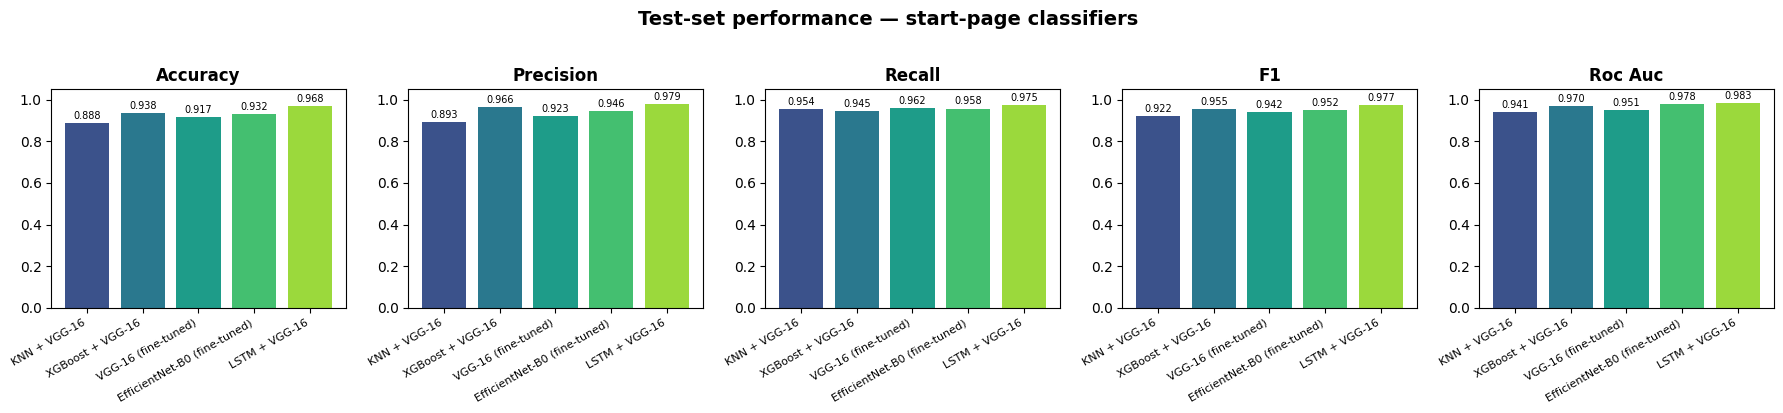

Figure saved to classifier_comparison.png


In [21]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))

for ax, metric in zip(axes, metrics):
    vals   = summary_df[metric].astype(float)
    colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(vals)))
    bars   = ax.bar(vals.index, vals.values, color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Test-set performance — start-page classifiers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(WORKSPACE / 'classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to classifier_comparison.png')